<!-- NINO26-CABECALHO v1 -->
# 3B — Alvo, eventos e ciclo de vida (NOAA/ONI local)

**Projeto NINO-BRASIL — Oceanografia Física UFPE — Thiago Vilar**  
**Código da fase/letra:** `3B`  ·  **Hipótese:** HIP0

## Descritivo (por que este notebook existe)
Deriva o catálogo local de eventos El Niño/La Niña pela regra NOAA/ONI (sem rótulo externo) e delimita a FAIXA de pico — o alvo de todas as análises de fase da coluna do mecanismo.

## Pergunta
Como os eventos locais nascem, crescem, atingem o pico e decaem por classe (fraco/moderado/forte/muito forte) e onde começa/termina a faixa de pico de cada evento?

## Desafio (hipótese a testar)
O critério local (ONI>=±0,5 °C por >=5 estações móveis) precisa reproduzir a cronologia NOAA e definir o pico como faixa reprodutível, não como um único mês.

## Metodologia (com referências)
Média móvel trimestral do SSTA, limiar ONI e classificação por pico; faixa de pico por fração do |ONI| máximo (Trenberth, 1997; Timmermann et al., 2018).

## Contrato de saídas — código predecessor único
Cada figura nasce do **mesmo** `registrar_figura(...)` que congela sua numeric-table sob o **mesmo código**, reescrevendo por **sobreposição** a cada execução. A fonte deve ser uma tabela persistida com sidecar e hash do mesmo `run_id`:

```python
from nino_brasil.viz import registrar_figura
registrar_figura(fig, "Fig_3B01", fase=3, bloco="B",
                 titulo=..., descricao=..., hipotese="HIP0",
                 notebook="notebooks/fase3/3B_alvo_eventos_ciclo_vida.ipynb",
                 run_id=run.run_id,
                 fontes={"<tabela>": tabela_path})   # Path + .manifest.json -> figures/fase3/<codigo>.png + numeric-tables/fase3/<codigo>/
```

| Código | Figura (`figures/fase3/<código>.png`) | Numeric-table (`numeric-tables/fase3/<código>/`) | Descrição |
|---|---|---|---|
| `Fig_3B01` | `Fig_3B01.png` | `Fig_3B01/` | trajetórias compostas por classe |
| `Fig_3B02` | `Fig_3B02.png` | `Fig_3B02/` | autocorrelação/persistência |
| `Fig_3B03` | `Fig_3B03.png` | `Fig_3B03/` | composto de SSTA no pico |
| `Fig_3B04` | `Fig_3B04.png` | `Fig_3B04/` | faixa de pico do ONI |

> Padrão em `docs/PADRAO_NOTEBOOKS.md`; compatibilidade por `python scripts/validar_figuras.py --strict --allow-render-extraction`; promoção por `python scripts/validar_figuras.py --strict`.

## Contrato científico central

As tabelas abaixo são geradas pelo executor F3 testado. Rótulos de fase/faixa de pico são retrospectivos; previsão usa apenas a tabela rolling-origin. O evento é a unidade independente.


In [1]:
from pathlib import Path
import json, os, subprocess, sys
import pandas as pd
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'pyproject.toml').exists())
PYTHON = sys.executable
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'smoke')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
assert MODE in {'smoke', 'official'}
print({'root': str(ROOT), 'python': PYTHON, 'mode': MODE, 'run_pipeline': RUN_PIPELINE})

ENSO_TYPE = os.environ.get('NINO26_ENSO_TYPE', '').strip()
assert ENSO_TYPE in {'', 'el_nino', 'la_nina'}
STATS = Path(os.environ.get('NINO26_PHASE3_STATS_DIR', ROOT/'data/processed/parquet/statistics'))


{'root': 'C:\\DEV\\NINO26', 'python': 'C:\\DEV\\NINO26\\.venv\\Scripts\\python.exe', 'mode': 'official', 'run_pipeline': False}


In [2]:
if RUN_PIPELINE:
    command=[PYTHON, str(ROOT/'scripts/phase3_en_ln.py')]
    if ENSO_TYPE: command.extend(['--enso-type', ENSO_TYPE])
    if MODE == 'smoke': command.append('--quick')
    subprocess.run(command, cwd=ROOT, check=True)


,table,exists,manifest
0,phase3_events_en_ln.csv,True,True
1,phase3_fases_semanais_en_ln.csv,True,True
2,phase3_event_lifecycle_en_ln.csv,True,True
3,phase3_peak_band_sensitivity.csv,True,True
4,phase3_rolling_origin_targets.csv,True,True


phase3_events_en_ln.csv


,event_id,tipo,classe,onset,pico,fim,faixa_pico_inicio,faixa_pico_fim,duracao_meses,oni_pico_c,magnitude_pico_c,limiar_evento_c,min_estacoes_consecutivas,fracao_faixa_pico,definicao_faixa_pico,modo_rotulo
0,el_nino_1982_1983,el_nino,muito_forte,1982-07-01,1983-01-01,1983-05-31,1982-11-01,1983-01-31,11,2.119732,2.119732,0.5,5,0.9,componente mensal contiguo que contem o extrem...,diagnostico_retrospectivo
1,la_nina_1983_1984,la_nina,moderado,1983-09-01,1983-11-01,1984-02-29,1983-11-01,1983-12-31,6,-1.209990,1.209990,0.5,5,0.9,componente mensal contiguo que contem o extrem...,diagnostico_retrospectivo
2,la_nina_1984_1986,la_nina,moderado,1984-04-01,1984-12-01,1986-04-30,1984-12-01,1985-01-31,25,-1.391642,1.391642,0.5,5,0.9,componente mensal contiguo que contem o extrem...,diagnostico_retrospectivo
3,el_nino_1986_1988,el_nino,moderado,1986-10-01,1987-08-01,1988-01-31,1987-08-01,1987-09-30,16,1.210545,1.210545,0.5,5,0.9,componente mensal contiguo que contem o extrem...,diagnostico_retrospectivo
4,la_nina_1988_1989,la_nina,muito_forte,1988-04-01,1988-11-01,1989-10-31,1988-11-01,1988-12-31,19,-2.124949,2.124949,0.5,5,0.9,componente mensal contiguo que contem o extrem...,diagnostico_retrospectivo
5,el_nino_1991_1992,el_nino,forte,1991-09-01,1992-01-01,1992-06-30,1992-01-01,1992-02-29,10,1.625388,1.625388,0.5,5,0.9,componente mensal contiguo que contem o extrem...,diagnostico_retrospectivo
6,el_nino_1994_1995,el_nino,fraco,1994-10-01,1994-12-01,1995-02-28,1994-11-01,1995-01-31,5,0.967545,0.967545,0.5,5,0.9,componente mensal contiguo que contem o extrem...,diagnostico_retrospectivo
7,la_nina_1995_1996,la_nina,fraco,1995-09-01,1995-11-01,1996-04-30,1995-10-01,1995-12-31,8,-0.971189,0.971189,0.5,5,0.9,componente mensal contiguo que contem o extrem...,diagnostico_retrospectivo
8,el_nino_1997_1998,el_nino,muito_forte,1997-06-01,1997-12-01,1998-04-30,1997-10-01,1998-01-31,11,2.145989,2.145989,0.5,5,0.9,componente mensal contiguo que contem o extrem...,diagnostico_retrospectivo
9,la_nina_1998_2001,la_nina,forte,1998-06-01,1999-12-01,2001-03-31,1999-12-01,2000-01-31,34,-1.704278,1.704278,0.5,5,0.9,componente mensal contiguo que contem o extrem...,diagnostico_retrospectivo


phase3_fases_semanais_en_ln.csv


,week_ending_sunday,fase,tipo,event_id,estado_enso,semana_relativa_pico,semana_no_evento,rotulo_disponivel_na_origem,modo_rotulo,fracao_faixa_pico
0,1981-01-04,neutro,neutro,NaN,neutro,NaN,NaN,False,diagnostico_retrospectivo,0.9
1,1981-01-11,neutro,neutro,NaN,neutro,NaN,NaN,False,diagnostico_retrospectivo,0.9
2,1981-01-18,neutro,neutro,NaN,neutro,NaN,NaN,False,diagnostico_retrospectivo,0.9
3,1981-01-25,neutro,neutro,NaN,neutro,NaN,NaN,False,diagnostico_retrospectivo,0.9
4,1981-02-01,neutro,neutro,NaN,neutro,NaN,NaN,False,diagnostico_retrospectivo,0.9
5,1981-02-08,neutro,neutro,NaN,neutro,NaN,NaN,False,diagnostico_retrospectivo,0.9
6,1981-02-15,neutro,neutro,NaN,neutro,NaN,NaN,False,diagnostico_retrospectivo,0.9
7,1981-02-22,neutro,neutro,NaN,neutro,NaN,NaN,False,diagnostico_retrospectivo,0.9
8,1981-03-01,neutro,neutro,NaN,neutro,NaN,NaN,False,diagnostico_retrospectivo,0.9
9,1981-03-08,neutro,neutro,NaN,neutro,NaN,NaN,False,diagnostico_retrospectivo,0.9


...

,event_id,tipo,classe,fase,inicio,fim,duracao_semanas,modo_rotulo
0,el_nino_1982_1983,el_nino,muito_forte,genese,1982-01-03,1982-06-27,26,diagnostico_retrospectivo
1,el_nino_1982_1983,el_nino,muito_forte,crescimento,1982-07-04,1982-10-31,18,diagnostico_retrospectivo
2,el_nino_1982_1983,el_nino,muito_forte,pico,1982-11-07,1983-01-30,13,diagnostico_retrospectivo
3,el_nino_1982_1983,el_nino,muito_forte,decaimento,1983-02-06,1983-05-29,17,diagnostico_retrospectivo
4,la_nina_1983_1984,la_nina,moderado,genese,1983-06-05,1983-08-28,13,diagnostico_retrospectivo
5,la_nina_1983_1984,la_nina,moderado,crescimento,1983-09-04,1983-10-30,9,diagnostico_retrospectivo
6,la_nina_1983_1984,la_nina,moderado,pico,1983-11-06,1983-12-25,8,diagnostico_retrospectivo
7,la_nina_1983_1984,la_nina,moderado,decaimento,1984-01-01,1984-02-26,9,diagnostico_retrospectivo
8,la_nina_1984_1986,la_nina,moderado,genese,1984-03-04,1984-03-25,4,diagnostico_retrospectivo
9,la_nina_1984_1986,la_nina,moderado,crescimento,1984-04-01,1984-11-25,35,diagnostico_retrospectivo


phase3_peak_band_sensitivity.csv


,event_id,tipo,pico,fracao_faixa_pico,faixa_pico_inicio,faixa_pico_fim,duracao_faixa_pico_meses,configuracao_canonica,modo_rotulo
0,el_nino_1982_1983,el_nino,1983-01-01,0.80,1982-11-01,1983-02-28,4,False,diagnostico_retrospectivo_sensibilidade
1,el_nino_1982_1983,el_nino,1983-01-01,0.90,1982-11-01,1983-01-31,3,True,diagnostico_retrospectivo_sensibilidade
2,el_nino_1982_1983,el_nino,1983-01-01,0.95,1982-12-01,1983-01-31,2,False,diagnostico_retrospectivo_sensibilidade
3,la_nina_1983_1984,la_nina,1983-11-01,0.80,1983-11-01,1983-12-31,2,False,diagnostico_retrospectivo_sensibilidade
4,la_nina_1983_1984,la_nina,1983-11-01,0.90,1983-11-01,1983-12-31,2,True,diagnostico_retrospectivo_sensibilidade
5,la_nina_1983_1984,la_nina,1983-11-01,0.95,1983-11-01,1983-12-31,2,False,diagnostico_retrospectivo_sensibilidade
6,la_nina_1984_1986,la_nina,1984-12-01,0.80,1984-11-01,1985-01-31,3,False,diagnostico_retrospectivo_sensibilidade
7,la_nina_1984_1986,la_nina,1984-12-01,0.90,1984-12-01,1985-01-31,2,True,diagnostico_retrospectivo_sensibilidade
8,la_nina_1984_1986,la_nina,1984-12-01,0.95,1984-12-01,1984-12-31,1,False,diagnostico_retrospectivo_sensibilidade
9,el_nino_1986_1988,el_nino,1987-08-01,0.80,1987-07-01,1987-10-31,4,False,diagnostico_retrospectivo_sensibilidade


phase3_rolling_origin_targets.csv


,origin_time,information_cutoff,target_time,horizon_weeks,signal_at_origin_c,target_signal_c,target_tipo,uses_future_features,evaluation_mode,target_fase,target_estado_enso,target_event_id,target_label_is_retrospective
0,1981-01-04,1981-01-04,1981-01-11,1,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
1,1981-01-04,1981-01-04,1981-02-01,4,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
2,1981-01-04,1981-01-04,1981-03-01,8,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
3,1981-01-04,1981-01-04,1981-03-29,12,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
4,1981-01-04,1981-01-04,1981-07-05,26,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
5,1981-01-11,1981-01-11,1981-01-18,1,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
6,1981-01-11,1981-01-11,1981-02-08,4,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
7,1981-01-11,1981-01-11,1981-03-08,8,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
8,1981-01-11,1981-01-11,1981-04-05,12,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True
9,1981-01-11,1981-01-11,1981-07-12,26,NaN,NaN,fora_da_amostra,False,rolling_origin_operacional,neutro,neutro,NaN,True


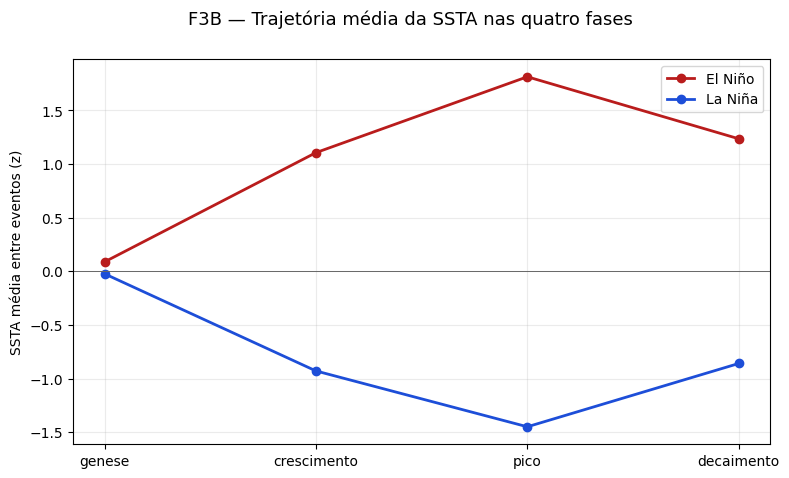

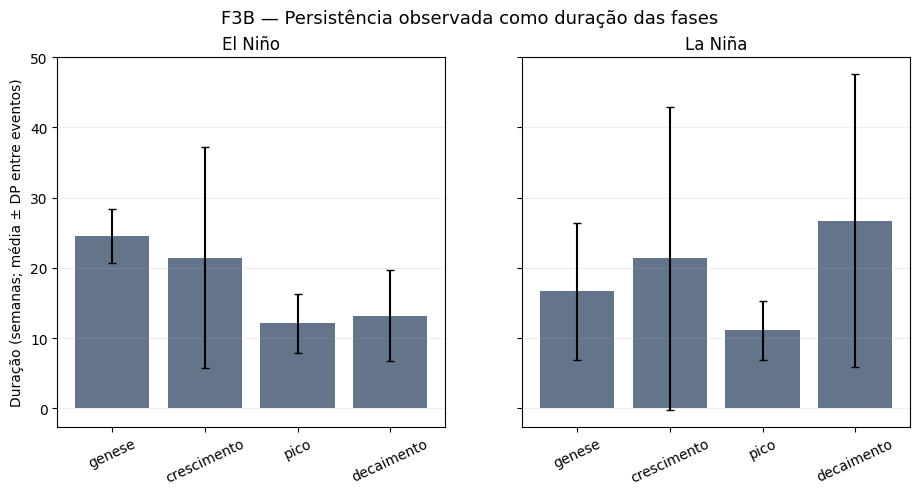

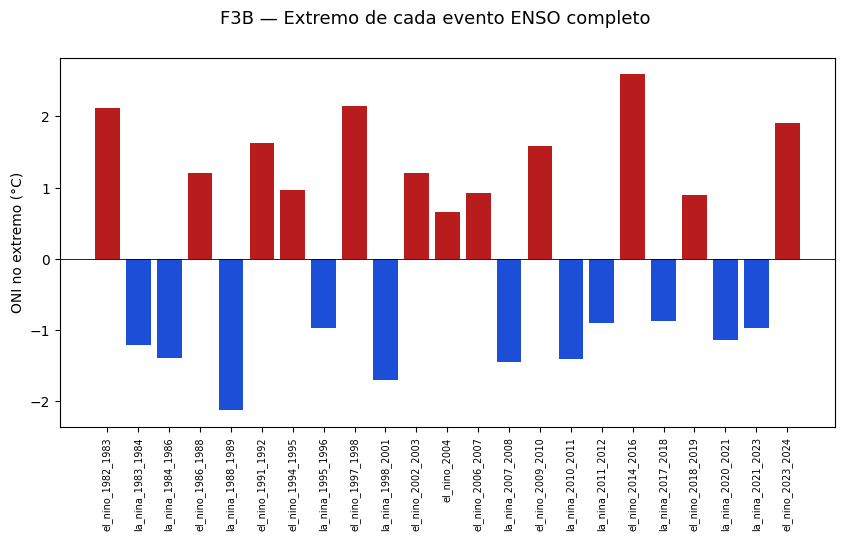

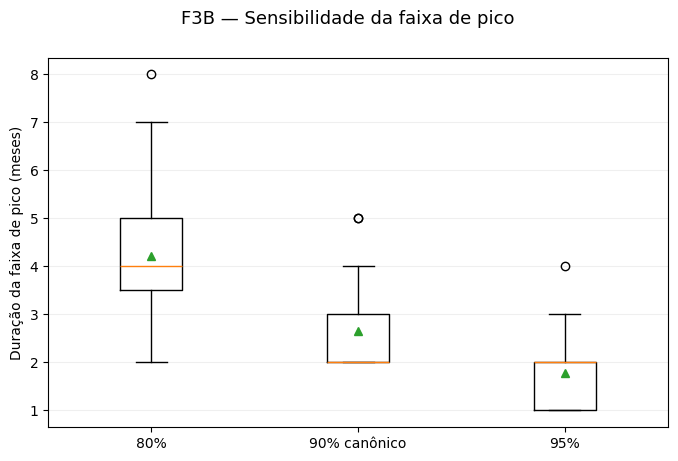

In [3]:
table_names=['phase3_events_en_ln.csv', 'phase3_fases_semanais_en_ln.csv', 'phase3_event_lifecycle_en_ln.csv', 'phase3_peak_band_sensitivity.csv', 'phase3_rolling_origin_targets.csv']
base = STATS/'pilots/quick' if MODE == 'smoke' else STATS
inventory=[]
for name in table_names:
    path=base/name
    inventory.append({'table':name,'exists':path.exists(),'manifest':path.with_suffix(path.suffix+'.manifest.json').exists()})
display(pd.DataFrame(inventory))
for name in table_names:
    path=base/name
    if path.exists():
        print(name); display(pd.read_csv(path).head(30))

sys.path.insert(0, str(ROOT/'scripts'))
from render_phase3_semantic_summaries import render_block
render_block('B')


## Interpretação permitida

`diagnostico_retrospectivo` descreve gênese/crescimento/faixa de pico/decaimento após o evento. `rolling_origin_operacional` mede previsão. Resultados alinhados ao pico conhecido não são hindcasts operacionais.


<!-- NINO26-REFERENCIAS v1 -->
## Referências Bibliográficas

1. Trenberth, K. E. (1997). The Definition of El Niño. *BAMS*, 78, 2771-2777. https://doi.org/10.1175/1520-0477(1997)078<2771:TDOENO>2.0.CO;2
2. Timmermann, A., et al. (2018). El Niño-Southern Oscillation complexity. *Nature*, 559, 535-545. https://doi.org/10.1038/s41586-018-0252-6

Relação completa em `Artigos_Referências/Referências_Bibliográficas.xls`.